In [1]:
import sys
import os

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

print("✅ Project root configured successfully!")
print(f"Folder proiect: {project_root}")

✅ Project root configured successfully!
Folder proiect: d:\Work\msd-system-identification-pid


In [2]:
# =============================================
# Notebook 01 - Open-Loop Simulation
# Mass-Spring-Damper System (MSD)
# =============================================

import numpy as np
import matplotlib.pyplot as plt
from src.model import MassSpringDamper
from src.visualization import Visualizer

%matplotlib inline

print("✅ Imports finalized. Notebook 01 - Open Loop Simulation")

✅ Imports finalized. Notebook 01 - Open Loop Simulation


In [3]:
# System parameters
m = 1.0   # mass (kg)
k = 10.0  # spring constant (N/m)
c = 2.0   # damping coefficient (Ns/m)

# Create system
msd = MassSpringDamper(m=m, k=k, c=c)
viz = Visualizer()

print(f"System created with the following parameters:")
print(f"   Mass (m)              = {m} kg")
print(f"   Spring constant (k)   = {k} N/m")
print(f"   Damping coefficient (c) = {c} Ns/m")

✅ Plots will be saved in folder: d:\Work\msd-system-identification-pid\figures
System created with the following parameters:
   Mass (m)              = 1.0 kg
   Spring constant (k)   = 10.0 N/m
   Damping coefficient (c) = 2.0 Ns/m


   📊 Plot saved: d:\Work\msd-system-identification-pid\figures\01_openloop_step_response.png


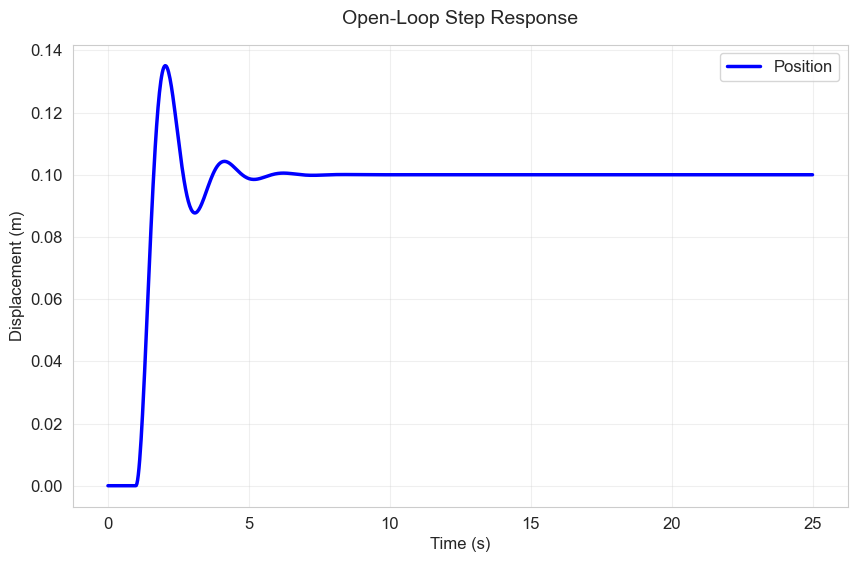

Final position (t=25s): 0.1000 m


In [4]:
# Step response simulation
F_step = msd.step_input(amplitude=1.0, start_time=1.0)

result = msd.simulate(t_span=(0, 25), F_func=F_step)

t_sim = result["t"]
x = result["x"]
v = result["x_dot"]

# Plot
viz.plot_response(
    t=t_sim,
    x=x,
    title="Open-Loop Step Response",
    filename="01_openloop_step_response.png",
    xlabel="Time (s)",
    ylabel="Displacement (m)",
    show=True
)

print(f"Final position (t=25s): {float(x[-1]):.4f} m")

✅ Plots will be saved in folder: d:\Work\msd-system-identification-pid\figures
✅ Plot saved: d:\Work\msd-system-identification-pid\figures\01_parameter_influence.png


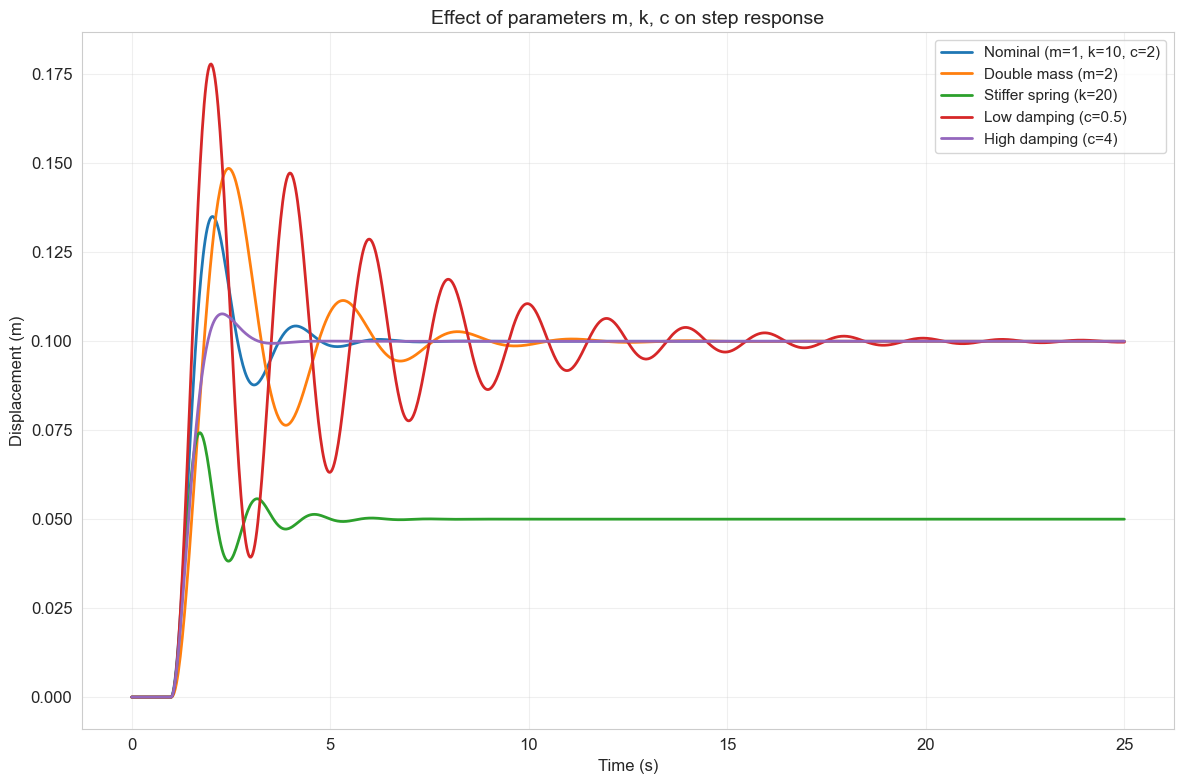

In [5]:
# Parameter influence analysis
params_variations = [
    (1.0, 10.0, 2.0, "Nominal (m=1, k=10, c=2)"),
    (2.0, 10.0, 2.0, "Double mass (m=2)"),
    (1.0, 20.0, 2.0, "Stiffer spring (k=20)"),
    (1.0, 10.0, 0.5, "Low damping (c=0.5)"),
    (1.0, 10.0, 4.0, "High damping (c=4)")
]

viz = Visualizer()

plt.figure(figsize=(12, 8))

for m_val, k_val, c_val, label in params_variations:
    sys = MassSpringDamper(m=m_val, k=k_val, c=c_val)
    result = sys.simulate((0, 25), F_func=sys.step_input(1.0, 1.0))
    t = result["t"]
    x = result["x"]
    plt.plot(t, x, linewidth=2, label=label)

plt.title("Effect of parameters m, k, c on step response", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_path = os.path.join(viz.save_path, "01_parameter_influence.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Plot saved: {save_path}")

plt.show()

✅ Multiple plot saved: d:\Work\msd-system-identification-pid\figures\01_position_velocity_acceleration.png


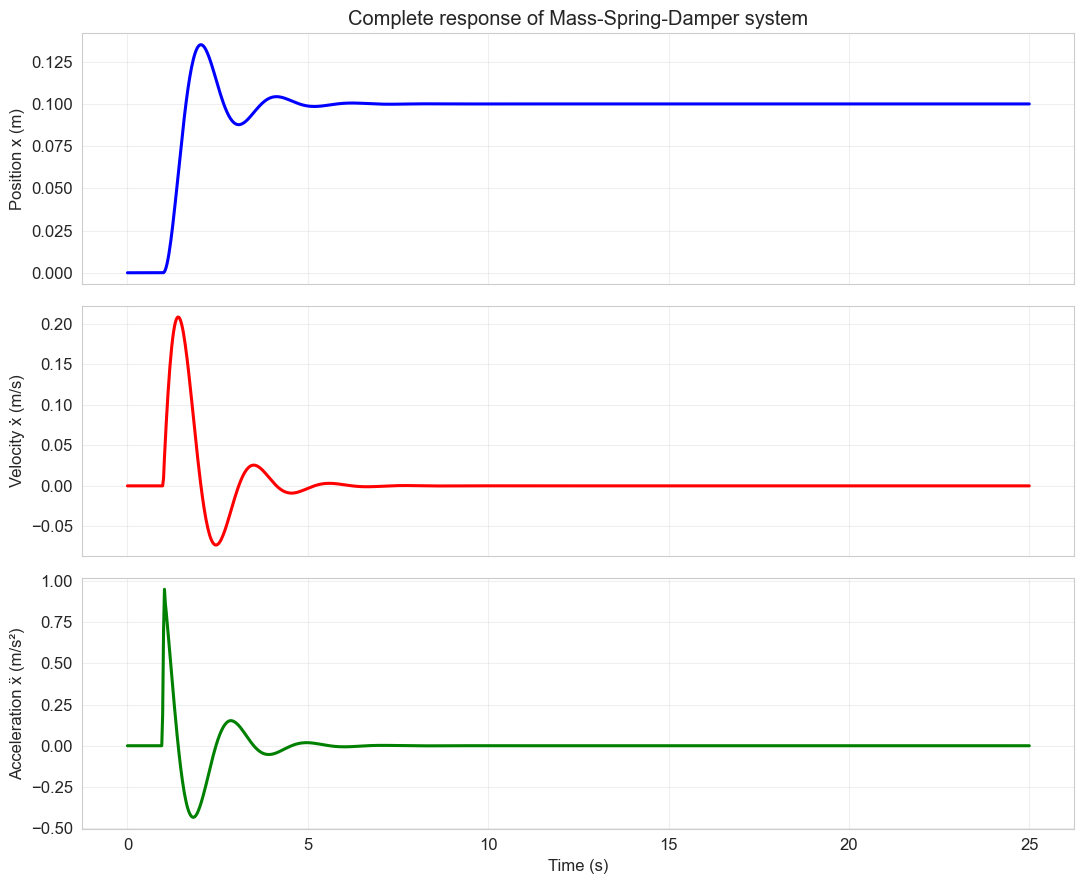

✅ Position, velocity and acceleration plots saved successfully!


In [6]:
# Multiple plots: Position, Velocity and Acceleration

result = msd.simulate(t_span=(0, 25), F_func=msd.step_input(1.0, 1.0))

t_sim = result["t"]
x = result["x"]
v = result["x_dot"]

# Calculate acceleration
a = np.gradient(v, t_sim)

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axs[0].plot(t_sim, x, 'b-', linewidth=2.2)
axs[0].set_ylabel("Position x (m)")
axs[0].set_title("Complete response of Mass-Spring-Damper system")

axs[1].plot(t_sim, v, 'r-', linewidth=2.2)
axs[1].set_ylabel("Velocity ẋ (m/s)")

axs[2].plot(t_sim, a, 'g-', linewidth=2.2)
axs[2].set_ylabel("Acceleration ẍ (m/s²)")
axs[2].set_xlabel("Time (s)")

for ax in axs:
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save using Visualizer
save_path = os.path.join(viz.save_path, "01_position_velocity_acceleration.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Multiple plot saved: {save_path}")

plt.show()

print("✅ Position, velocity and acceleration plots saved successfully!")

## Conclusions - Stage 1: Open-Loop Simulation

### Key Observations:

- The system is a **second-order underdamped system** with the nominal parameters (m=1 kg, k=10 N/m, c=2 Ns/m).
- The step response shows a clear overshoot followed by damped oscillations that settle to a steady-state value of 0.1 m.
- **Mass (m)**: Increasing the mass makes the system slower and increases the overshoot.
- **Spring constant (k)**: A stiffer spring increases the natural frequency and reduces settling time.
- **Damping coefficient (c)**: Higher damping reduces oscillations and overshoot, making the response more stable.

### What I Learned:

- How to numerically simulate a second-order mechanical system using `scipy.integrate.solve_ivp`
- The physical influence of each parameter (m, k, c) on the dynamic behavior
- The importance of analyzing not only position, but also velocity and acceleration to fully understand system dynamics
- Good practices for visualization and result interpretation


